In [1]:
# IPython extension to reload modules before executing user code.
# useful to see immediate results in notebook when modifying imported scripts
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os


# Add the ../py directory to sys.path
# This allows importing modules from the py directory as if they were in the current directory
module_path = os.path.abspath(os.path.join(os.getcwd(), '..', 'py'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Verify it works
print(f"Added to path: {module_path}")

Added to path: /Users/eyal/projects/elzurdo/dpitg/py


In [3]:
from utils import print_env_info, report_accounting_size

from utils_viz import (
    FIG_WIDTH,
    FIG_HEIGHT,
    SMALL_SIZE,
    MEDIUM_SIZE,
    BIGGER_SIZE,
    # plot_sample_pdf_methods,
    # viz_sequence_stats
)

from utils_experiments_binomial import (
    BinaryAccounting,
    BinomialSimulation,
    BinomialHypothesis, 
    run_simulations_and_analysis_report,
    CI_FRACTION,
    # stop_decision_multiple_sequences_multiple_methods,
    # sequence_to_iteration_stats,
    # SEQUENCE_HANDPICKED,
    # stats_dict_to_df,
    )


from utils_experiments_shared import (
    SEED,
    report_success_rates_multiple_algos
)

In [4]:
print_env_info()

Last run: 2026-06-30 08:46:34.648028
Python: 3.10.13
Platform: macOS-13.0-x86_64-i386-64bit
pandas: 2.3.3
numpy: 2.2.6
scipy: 1.15.3
matplotlib: 3.10.9
notebook: 7.6.0


In [5]:
plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["figure.figsize"] = FIG_WIDTH, FIG_HEIGHT
# plt.rcParams["hatch.linewidth"] = 0.2

plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

# Aux

In [6]:
# ci_frac_str = f"{CI_FRACTION}".replace(".","pt")

# binomial_accounting_file = f"cache/binary_accounting_{ci_frac_str}.pkl"

# print(binomial_accounting_file)

In [8]:
# used for storing an linking to binary calucations already performed
binary_accounting = BinaryAccounting(ci_fraction=CI_FRACTION)
binary_accounting.load_or_create()

print(binary_accounting.dict_successes_failures_counter, binary_accounting.dict_successes_failures_hdi_limits)
print("-" * 20)
# report_accounting_size(binary_accounting)

Filepath for BinaryAccounting: cache/binary_accounting_0pt95.pkl
Loaded cache: 34,285 entries from cache/binary_accounting_0pt95.pkl
{} {(10, 20): (np.float64(0.17262782153411607), np.float64(0.5002247113850005)), (20, 10): (np.float64(0.49977528861499954), np.float64(0.8273721784658838)), (11, 22): (np.float64(0.17945436978149346), np.float64(0.4926564865758776)), (np.int64(1), np.int64(0)): (np.float64(0.2236067977499792), np.float64(1.0)), (np.int64(1), np.int64(1)): (np.float64(0.050000000000000114), np.float64(1.0)), (np.int64(2), np.int64(1)): (np.float64(0.2236067977499792), np.float64(1.0)), (np.int64(3), np.int64(1)): (np.float64(0.36840314986403894), np.float64(1.0)), (np.int64(3), np.int64(2)): (np.float64(0.2276839810020331), np.float64(0.9561996888783482)), (np.int64(4), np.int64(2)): (np.float64(0.3298593927971026), np.float64(0.9739781677368797)), (np.int64(4), np.int64(3)): (np.float64(0.23871018036896152), np.float64(0.8951729470956987)), (np.int64(4), np.int64(4)): (n

# Experiments

## Fair Coin Sequences

In [14]:
θ_true = 0.5

N_EXPERIMENTS = 2000 # 2000
N_SAMPLES = 1500  # in paper called M

In [15]:
%%time

# was called synth_0pt5
sequences_0pt5 = BinomialSimulation(
    success_rate=θ_true,
    n_samples = N_SAMPLES,
    n_experiments = N_EXPERIMENTS,
    seed=SEED)

Generating synthetic data with parameter values:
0.5: true success rate
2000: experiments
1500: sample size per experiment
CPU times: user 70.4 ms, sys: 6.15 ms, total: 76.6 ms
Wall time: 75.6 ms


## Hypothesis

In [16]:
θ_null = 0.5
dsuccess_rate = 0.05
rope_precision_fraction = 0.8

In [17]:
hypothesis_0pt5 = BinomialHypothesis(
    success_rate_null=θ_null, 
    dsuccess_rate=dsuccess_rate, 
    rope_precision_fraction=rope_precision_fraction)

0.5: null hypothesis
0.45: ROPE min
0.55: ROPE max
--------------------
0.08: Precision Goal


In [18]:
%%time
# Timing sensitive to how complete binary_accounting is.
# From empty when setting:
# tbd
# tbd
# I takes ~ X minutes on macOS-13.0-x86_64-i386-64bit.

hypothesis_0pt5.run_hypothesis_on_experiments(sequences_0pt5.experiments, binary_accounting)


,accept,reject,conclusive,inconclusive,stop_iter_mean,stop_iter_std,success_rate_mean,success_rate_std
hdi_rope,0.9210,0.061,0.9820,0.0180,592.9835,290.737790,0.498253,0.051782
pitg,0.3670,0.000,0.3670,0.6330,598.2090,1.457526,0.499978,0.020554
dpitg,0.9765,0.000,0.9765,0.0235,740.9665,221.187573,0.500032,0.013120


CPU times: user 3min 5s, sys: 757 ms, total: 3min 5s
Wall time: 3min 7s


In [19]:
binary_accounting.save()

Cache saved: 79,058 entries to cache/binary_accounting_0pt95.pkl


In [21]:
# TODO: why do the number of elements/entries not agree?
report_accounting_size(binary_accounting)

Binary Accounting Report
78,501 elements in 11.49 MBytes)
Most frequent count value: 593 (appears 78 times (of 78,501 0.10%))
Max sum 1,500
e.g, key (np.int64(799), np.int64(701)) appears 2 time(s) yiedling (np.float64(0.5074142760260834), np.float64(0.5578881163957048)) HDI limits



viz_epitg separate


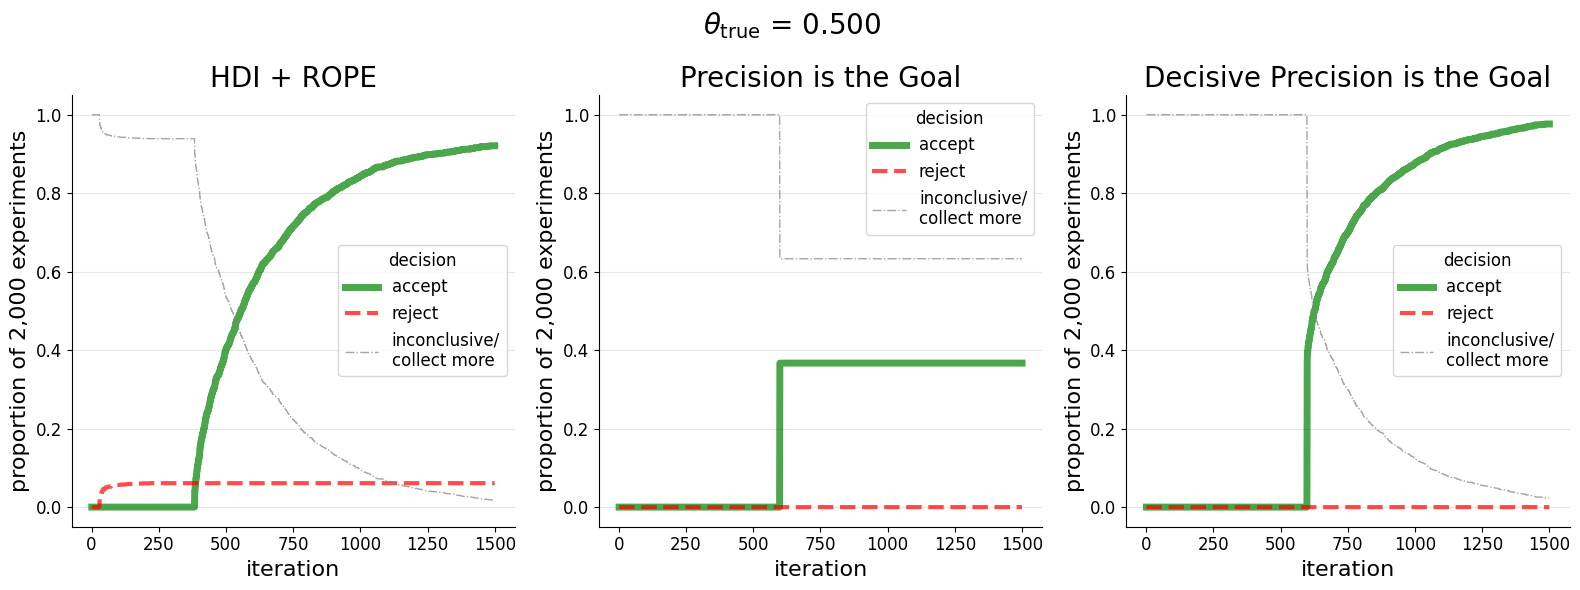

In [22]:
hypothesis_0pt5.plot_decision_rates(sequences_0pt5.success_rate, viz_epitg="separate")

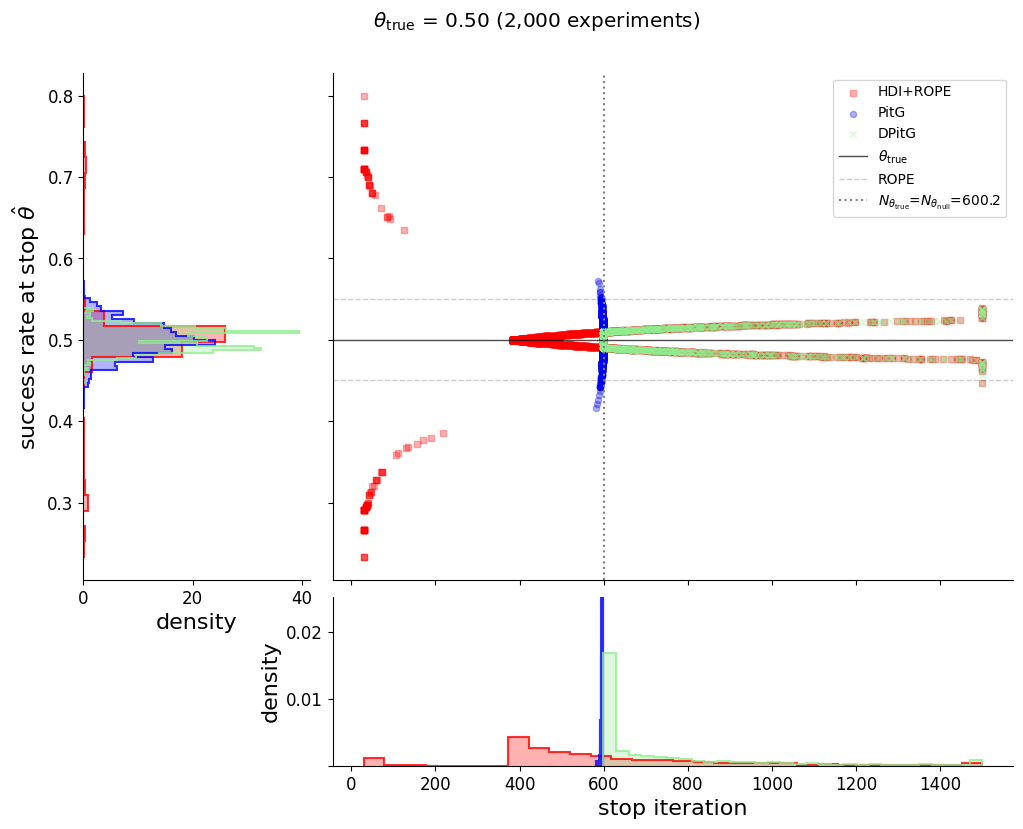

In [23]:
hypothesis_0pt5.plot_stop_iter_sample_rates(success_rate=sequences_0pt5.success_rate, title=None)

In [24]:
# Summary Stats
df_θtrue0pt5_θnull0pt5 = report_success_rates_multiple_algos(hypothesis_0pt5.method_df_stats.copy())

count  param_frac  param_mean  param_std  param_p25  \
algorithm group                                                               
pitg      overall        2000      1.0000    0.499978   0.020554   0.485810   
          conclusive      734      0.3670    0.500293   0.005508   0.495826   
          inconclusive   1266      0.6330    0.499794   0.025494   0.479933   
          accept          734      0.3670    0.500293   0.005508   0.495826   
dpitg     overall        2000      1.0000    0.500032   0.013120   0.489465   
          conclusive     1953      0.9765    0.499973   0.012220   0.489499   
          inconclusive     47      0.0235    0.502454   0.033731   0.470000   
          accept         1953      0.9765    0.499973   0.012220   0.489499   
hdi_rope  overall        2000      1.0000    0.498253   0.051782   0.491803   
          conclusive     1964      0.9820    0.498114   0.052057   0.491892   
          inconclusive     36      0.0180    0.505870   0.033090   0.471333   
          accept         1842      0.9210    0.499911   0.010597   0.492620   
          reject          122      0.0610    0.470976   0.203625   0.294118   

                        param_median  param_p75  stop_iter_mean  \
algorithm group                                                   
pitg      overall           0.500835   0.514190      598.209000   
          conclusive        0.500835   0.504174      599.000000   
          inconclusive      0.489149   0.520067      597.750395   
          accept            0.500835   0.504174      599.000000   
dpitg     overall           0.500835   0.510501      740.966500   
          conclusive        0.500835   0.510433      722.699949   
          inconclusive      0.526667   0.533667     1500.000000   
          accept            0.500835   0.510433      722.699949   
hdi_rope  overall           0.500000   0.508057      592.983500   
          conclusive        0.500000   0.507519      576.357943   
          inconclusive      0.528000   0.533500     1500.000000   
          accept            0.500000   0.507435      611.389794   
          reject            0.337838   0.702027       47.434426   

                        stop_iter_std  stop_iter_p25  stop_iter_median  \
algorithm group                                                          
pitg      overall            1.457526          598.0             599.0   
          conclusive         0.000000          599.0             599.0   
          inconclusive       1.668382          597.0             598.0   
          accept             0.000000          599.0             599.0   
dpitg     overall          221.187573          599.0             627.0   
          conclusive       189.462560          599.0             623.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           189.462560          599.0             623.0   
hdi_rope  overall          290.737790          415.0             523.0   
          conclusive       265.922483          413.0             519.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           235.712841          426.5             536.0   
          reject            33.382083           31.0              34.0   

                        stop_iter_p75  conclusive_mean  accept_mean  \
algorithm group                                                       
pitg      overall              599.00           0.3670     0.367000   
          conclusive           599.00           1.0000     1.000000   
          inconclusive         599.00           0.0000     0.000000   
          accept               599.00           1.0000     1.000000   
dpitg     overall              794.00           0.9765     0.976500   
          conclusive           775.00           1.0000     1.000000   
          inconclusive        1500.00           0.0000     0.000000   
          accept               775.00           1.0000     1.000000   
hdi_rope  o

In [25]:
algo_names = ["hdi_rope", "pitg", "dpitg"]

cols_overall = ["count", "conclusive_mean",  "stop_iter_median", "stop_iter_p25", "stop_iter_p75"]

df_θtrue0pt5_θnull0pt5.reset_index().query("group == 'overall'").set_index("algorithm").loc[algo_names][cols_overall]

,count,conclusive_mean,stop_iter_median,stop_iter_p25,stop_iter_p75
algorithm,,,,,
hdi_rope,2000,0.9820,523.0,415.0,721.0
pitg,2000,0.3670,599.0,598.0,599.0
dpitg,2000,0.9765,627.0,599.0,794.0


In [26]:
cols_conclusive = ["count", "accept_mean", "reject_mean", "param_median", "param_p25", "param_p75", "stop_iter_median", "stop_iter_p25", "stop_iter_p75"]

df_θtrue0pt5_θnull0pt5.reset_index().query("group == 'conclusive'").set_index("algorithm").loc[algo_names][cols_conclusive]

,count,accept_mean,reject_mean,param_median,param_p25,param_p75,stop_iter_median,stop_iter_p25,stop_iter_p75
algorithm,,,,,,,,,
hdi_rope,1964,0.937882,0.062118,0.500000,0.491892,0.507519,519.0,413.0,706.0
pitg,734,1.000000,0.000000,0.500835,0.495826,0.504174,599.0,599.0,599.0
dpitg,1953,1.000000,0.000000,0.500835,0.489499,0.510433,623.0,599.0,775.0


In [27]:
hypothesis_0pt5.decision_correctness(θ_true)

hypothesis_0pt5.df_experiment_correctness.head(4)

,hdi_rope_decision_iteration,hdi_rope_accept,hdi_rope_reject_below,hdi_rope_reject_above,hdi_rope_inconclusive,hdi_rope_param_value,hdi_rope_decision_correct,pitg_decision_iteration,pitg_accept,pitg_reject_below,...,pitg_inconclusive,pitg_param_value,pitg_decision_correct,dpitg_decision_iteration,dpitg_accept,dpitg_reject_below,dpitg_reject_above,dpitg_inconclusive,dpitg_param_value,dpitg_decision_correct
experiment_idx,,,,,,,,,,,,,,,,,,,,,
0,640,True,False,False,False,0.510938,True,598,False,False,...,True,0.521739,True,640,True,False,False,False,0.510938,True
1,502,True,False,False,False,0.505976,True,599,True,False,...,False,0.505843,True,599,True,False,False,False,0.505843,True
2,398,True,False,False,False,0.5,True,599,True,False,...,False,0.504174,True,599,True,False,False,False,0.504174,True
3,496,True,False,False,False,0.493952,True,599,True,False,...,False,0.492487,True,599,True,False,False,False,0.492487,True


# Examining Individual Sequences

## Sequences with Disagreeing Stops

In [28]:
# experiment ids for which:
# - HDI_ROPE method had success rate > 0.55
# - PITG method was inconclusive
# - DPITG method was conclusive

experiment_idxs = list(sorted(set(hypothesis_0pt5.method_df_stats["pitg"].query("inconclusive").index) &\
set(hypothesis_0pt5.method_df_stats["dpitg"].query("accept").index) &\
set(hypothesis_0pt5.method_df_stats["hdi_rope"].query("success_rate > 0.55").index)))
len(experiment_idxs)

35

1011010001100100001011111111100101011011100011111100101001101111111101110011110011100111100010100010111101011111100011111111111000001010010011000000011010001000100000000100101110011101001110000100101100110100001010111100111111110111001010110111001001010100111101010011110111001011100100110010100100010010110101010101001111001100110110111011100101000101100110011001011110011111011101010100011011101111000101101010101010101111000010001110110010101011001001100100011011011111001110000100110010000010101100101011010000011001010001101011100101011010001001101001001001101101001010111000011010001111110010011111001000111000110001010010101011100100001101111011110111001110110100100010010011110111001000001000111000000100101111110111101010001101100100011001010111100000010011011111000000010100110010011100010101000001011111001011100110110101110010000111100100111111100111111111001110110100001011101100011001110010000100111011001110001100101000000011011100001100111001110111001010011010100110010101000110000000

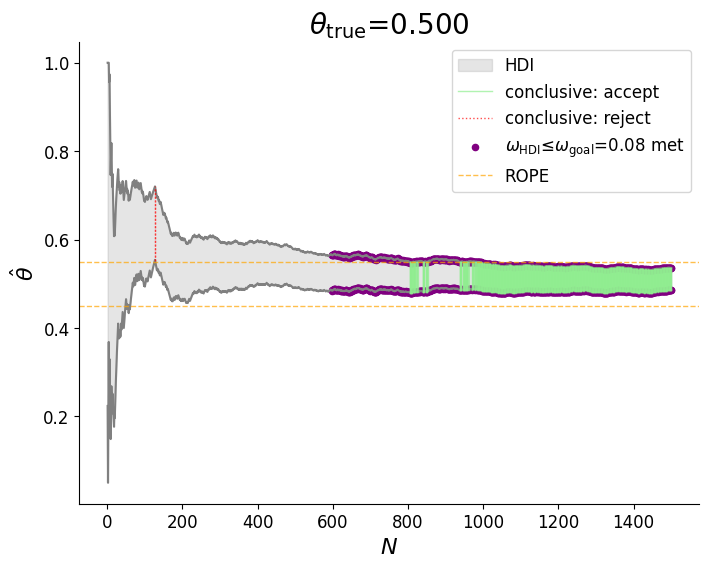

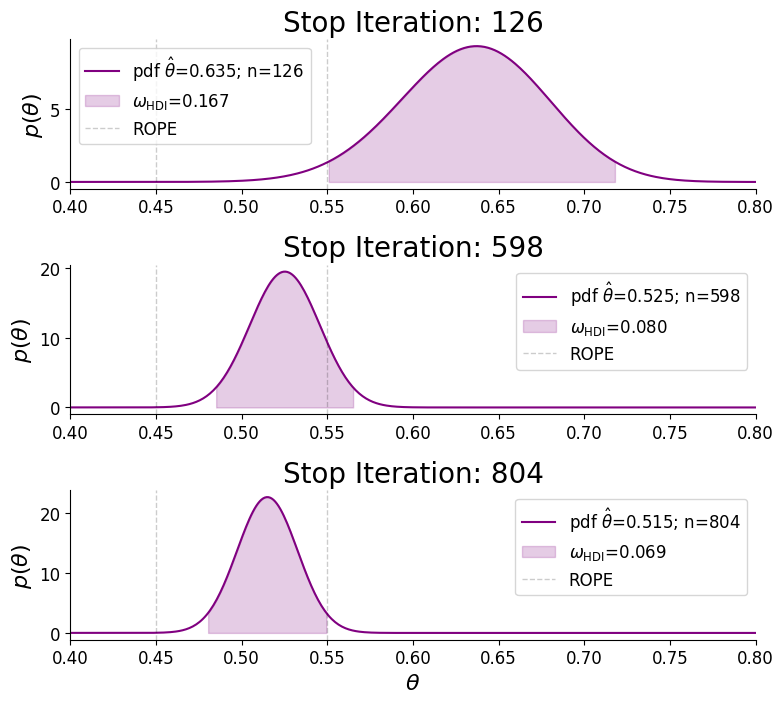

In [29]:
# Visualising outcomes of one experiment

#iexperiment = experiment_idxs[0]
#iexperiment = experiment_idxs[1]  # good example
iexperiment = experiment_idxs[2]  # good example. HAND PICKED FOR PAPER.

# for viz
method_names = ["hdi_rope", "pitg", "dpitg"]

print("".join([f"{b_}" for b_ in hypothesis_0pt5.experiments[iexperiment,:] ]))

xlim = (0.4, 0.8)
df_experiment_results = hypothesis_0pt5.one_experiment_all_iterations(iexperiment, binary_accounting=binary_accounting, viz=True, θ_true=θ_true, method_names=method_names, xlim=xlim)



# Goal Sensitivity

In [30]:
ωgoal_to_experiments = {
    0.08: {
        "synth": sequences_0pt5,
        "hypothesis": hypothesis_0pt5,
        "df_stats": df_θtrue0pt5_θnull0pt5.copy()
    }    
}

Generating synthetic data with parameter values:
0.5: true success rate
2000: experiments
1500: sample size per experiment
0.5: null hypothesis
0.45: ROPE min
0.55: ROPE max
--------------------
0.07: Precision Goal


,accept,reject,conclusive,inconclusive,stop_iter_mean,stop_iter_std,success_rate_mean,success_rate_std
hdi_rope,0.9210,0.061,0.9820,0.0180,592.9835,290.737790,0.498253,0.051782
pitg,0.5940,0.000,0.5940,0.4060,782.1150,1.408107,0.499753,0.017560
dpitg,0.9745,0.000,0.9745,0.0255,865.3450,171.850736,0.499766,0.013782


viz_epitg separate


count  param_frac  param_mean  param_std  param_p25  \
algorithm group                                                               
pitg      overall        2000      1.0000    0.499753   0.017560   0.487867   
          conclusive     1188      0.5940    0.500113   0.008164   0.492976   
          inconclusive    812      0.4060    0.499226   0.025730   0.477593   
          accept         1188      0.5940    0.500113   0.008164   0.492976   
dpitg     overall        2000      1.0000    0.499766   0.013782   0.487867   
          conclusive     1949      0.9745    0.499773   0.012856   0.487867   
          inconclusive     51      0.0255    0.499477   0.033976   0.467667   
          accept         1949      0.9745    0.499773   0.012856   0.487867   
hdi_rope  overall        2000      1.0000    0.498253   0.051782   0.491803   
          conclusive     1964      0.9820    0.498114   0.052057   0.491892   
          inconclusive     36      0.0180    0.505870   0.033090   0.471333   
          accept         1842      0.9210    0.499911   0.010597   0.492620   
          reject          122      0.0610    0.470976   0.203625   0.294118   

                        param_median  param_p75  stop_iter_mean  \
algorithm group                                                   
pitg      overall           0.499361   0.512133      782.115000   
          conclusive        0.500639   0.507024      782.926768   
          inconclusive      0.484655   0.522407      780.927340   
          accept            0.500639   0.507024      782.926768   
dpitg     overall           0.499361   0.512133      865.345000   
          conclusive        0.499361   0.510856      848.737814   
          inconclusive      0.473333   0.533000     1500.000000   
          accept            0.499361   0.510856      848.737814   
hdi_rope  overall           0.500000   0.508057      592.983500   
          conclusive        0.500000   0.507519      576.357943   
          inconclusive      0.528000   0.533500     1500.000000   
          accept            0.500000   0.507435      611.389794   
          reject            0.337838   0.702027       47.434426   

                        stop_iter_std  stop_iter_p25  stop_iter_median  \
algorithm group                                                          
pitg      overall            1.408107          782.0             783.0   
          conclusive         0.260627          783.0             783.0   
          inconclusive       1.552498          780.0             781.0   
          accept             0.260627          783.0             783.0   
dpitg     overall          171.850736          783.0             783.0   
          conclusive       139.587525          783.0             783.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           139.587525          783.0             783.0   
hdi_rope  overall          290.737790          415.0             523.0   
          conclusive       265.922483          413.0             519.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           235.712841          426.5             536.0   
          reject            33.382083           31.0              34.0   

                        stop_iter_p75  conclusive_mean  accept_mean  \
algorithm group                                                       
pitg      overall              783.00           0.5940     0.594000   
          conclusive           783.00           1.0000     1.000000   
          inconclusive         782.00           0.0000     0.000000   
          accept               783.00           1.0000     1.000000   
dpitg     overall              851.00           0.9745     0.974500   
          conclusive           832.00           1.0000     1.000000   
          inconclusive        1500.00           0.0000     0.000000   
          accept               832.00           1.0000     1.000000   
hdi_rope  o

Generating synthetic data with parameter values:
0.5: true success rate
2000: experiments
1500: sample size per experiment
0.5: null hypothesis
0.45: ROPE min
0.55: ROPE max
--------------------
0.09: Precision Goal


...

Generating synthetic data with parameter values:
0.5: true success rate
2000: experiments
1500: sample size per experiment
0.5: null hypothesis
0.45: ROPE min
0.55: ROPE max
--------------------
0.1: Precision Goal


,accept,reject,conclusive,inconclusive,stop_iter_mean,stop_iter_std,success_rate_mean,success_rate_std
hdi_rope,0.9210,0.0610,0.982,0.018,592.9835,290.737790,0.498253,0.051782
pitg,0.0000,0.0000,0.000,1.000,382.1875,1.457191,0.499679,0.025725
dpitg,0.9785,0.0005,0.979,0.021,634.9715,268.326932,0.499852,0.011888


viz_epitg separate


count  param_frac  param_mean  param_std  param_p25  \
algorithm group                                                               
pitg      overall        2000      1.0000    0.499679   0.025725   0.483029   
          inconclusive   2000      1.0000    0.499679   0.025725   0.483029   
dpitg     overall        2000      1.0000    0.499852   0.011888   0.492502   
          conclusive     1958      0.9790    0.499811   0.010970   0.492537   
          inconclusive     42      0.0210    0.501762   0.033811   0.469667   
          accept         1957      0.9785    0.499862   0.010738   0.492537   
          reject            1      0.0005    0.400000        NaN   0.400000   
hdi_rope  overall        2000      1.0000    0.498253   0.051782   0.491803   
          conclusive     1964      0.9820    0.498114   0.052057   0.491892   
          inconclusive     36      0.0180    0.505870   0.033090   0.471333   
          accept         1842      0.9210    0.499911   0.010597   0.492620   
          reject          122      0.0610    0.470976   0.203625   0.294118   

                        param_median  param_p75  stop_iter_mean  \
algorithm group                                                   
pitg      overall           0.498695   0.516971      382.187500   
          inconclusive      0.498695   0.516971      382.187500   
dpitg     overall           0.500000   0.507491      634.971500   
          conclusive        0.500000   0.507435      616.416241   
          inconclusive      0.526667   0.533167     1500.000000   
          accept            0.500000   0.507435      616.539601   
          reject            0.400000   0.400000      375.000000   
hdi_rope  overall           0.500000   0.508057      592.983500   
          conclusive        0.500000   0.507519      576.357943   
          inconclusive      0.528000   0.533500     1500.000000   
          accept            0.500000   0.507435      611.389794   
          reject            0.337838   0.702027       47.434426   

                        stop_iter_std  stop_iter_p25  stop_iter_median  \
algorithm group                                                          
pitg      overall            1.457191          382.0             383.0   
          inconclusive       1.457191          382.0             383.0   
dpitg     overall          268.326932          430.0             543.0   
          conclusive       239.041936          428.0             538.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           239.040685          428.0             538.0   
          reject                  NaN          375.0             375.0   
hdi_rope  overall          290.737790          415.0             523.0   
          conclusive       265.922483          413.0             519.0   
          inconclusive       0.000000         1500.0            1500.0   
          accept           235.712841          426.5             536.0   
          reject            33.382083           31.0              34.0   

                        stop_iter_p75  conclusive_mean  accept_mean  \
algorithm group                                                       
pitg      overall              383.00            0.000     0.000000   
          inconclusive         383.00            0.000     0.000000   
dpitg     overall              747.50            0.979     0.978500   
          conclusive           729.50            1.000     0.999489   
          inconclusive        1500.00            0.000     0.000000   
          accept               730.00            1.000     1.000000   
          reject               375.00            1.000     0.000000   
hdi_rope  overall              721.00            0.982     0.921000   
          conclusive           706.00            1.000     0.937882   
          inconclusive        1500.00            0.000     0.000000   
          accept               724.50            1.000     1.000000   
          reject  

CPU times: user 31.6 s, sys: 155 ms, total: 31.8 s
Wall time: 31.9 s


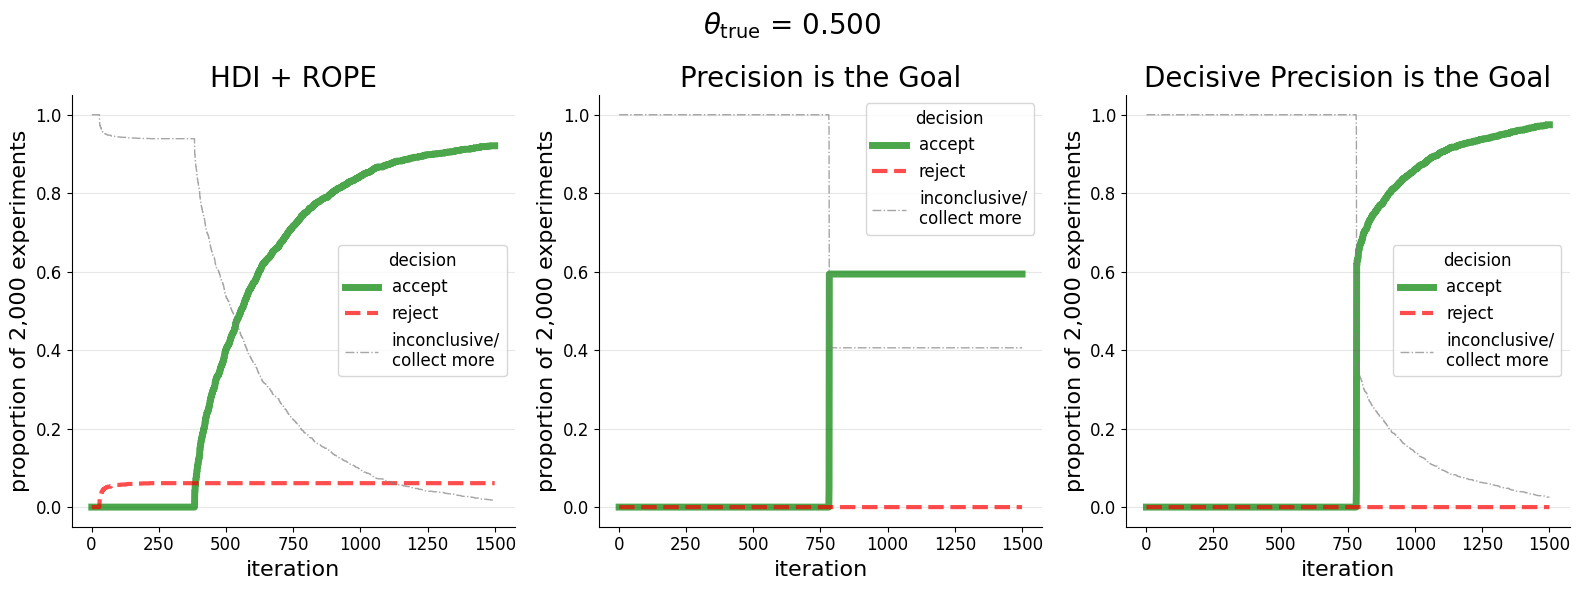

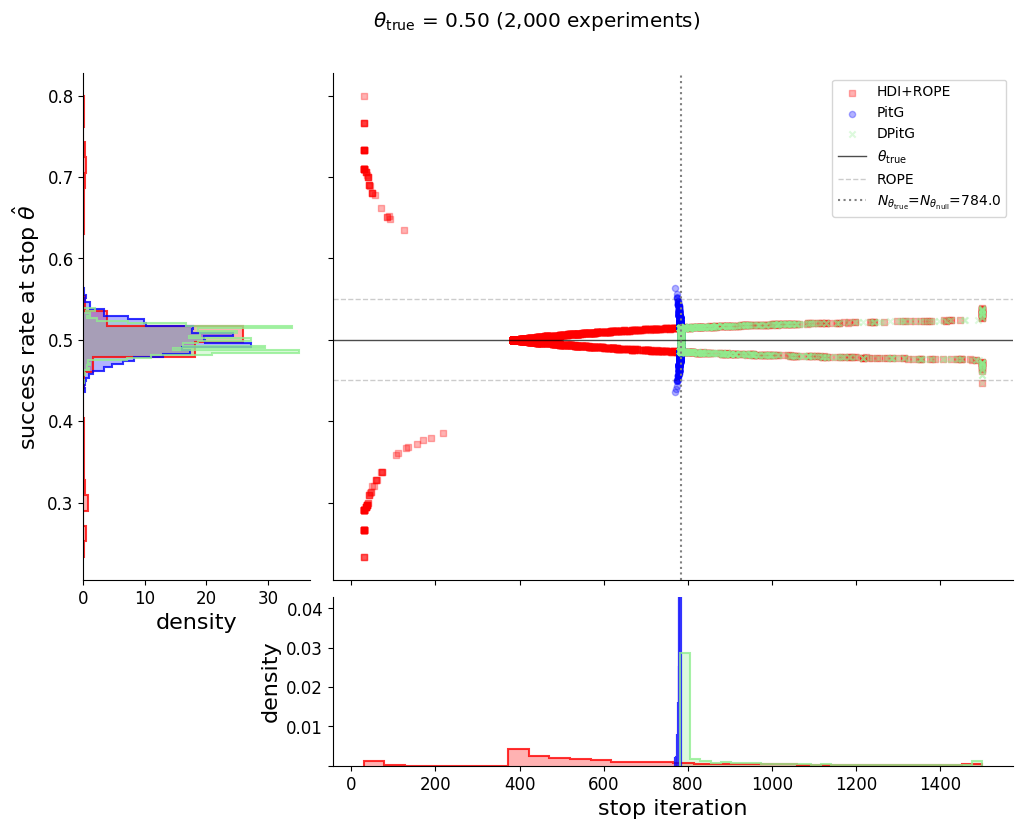

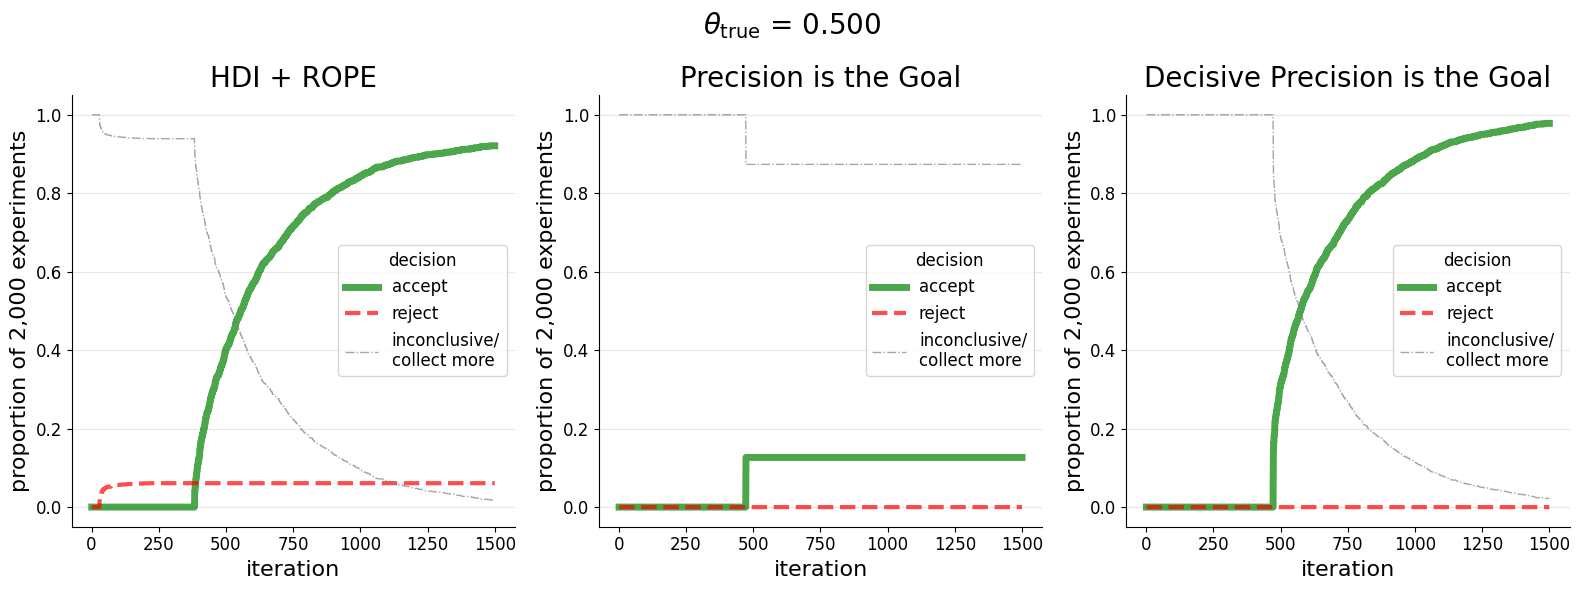

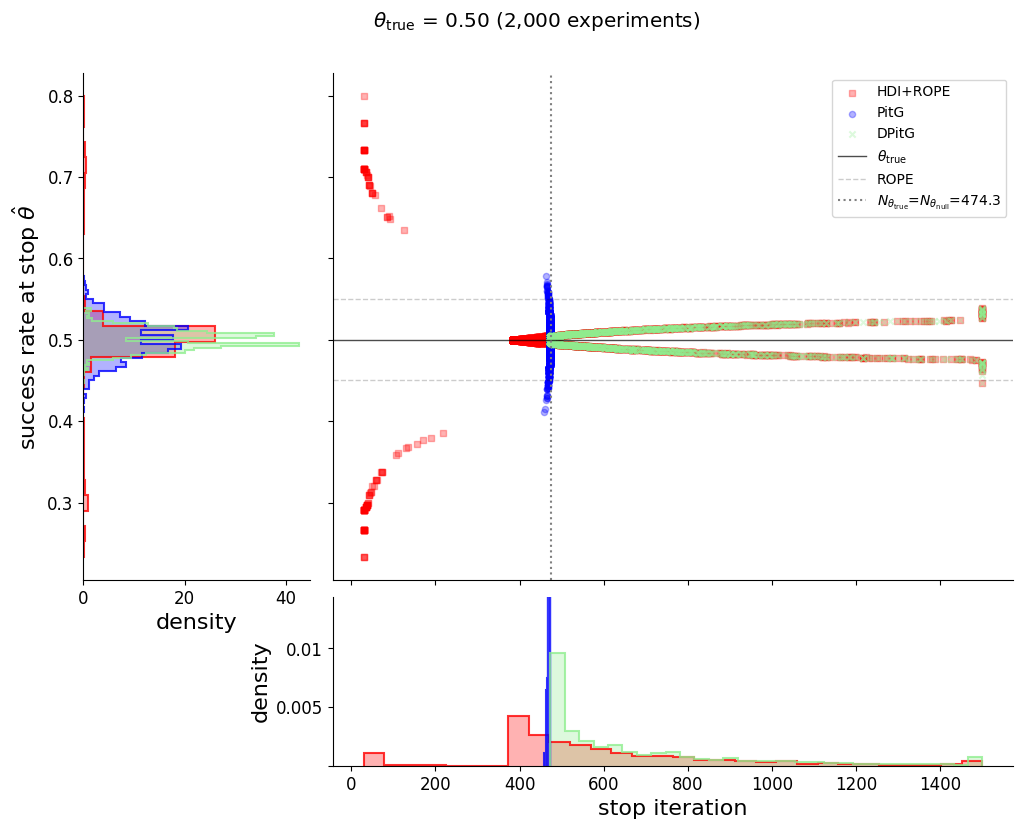

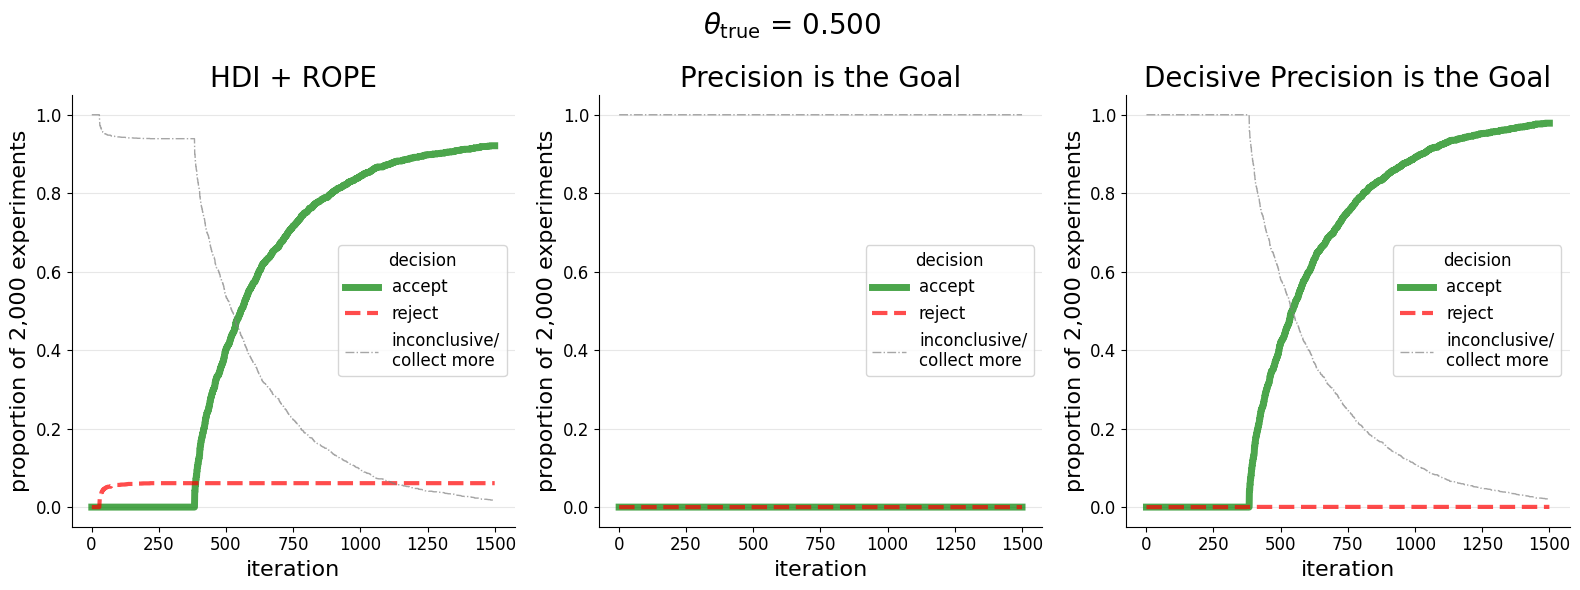

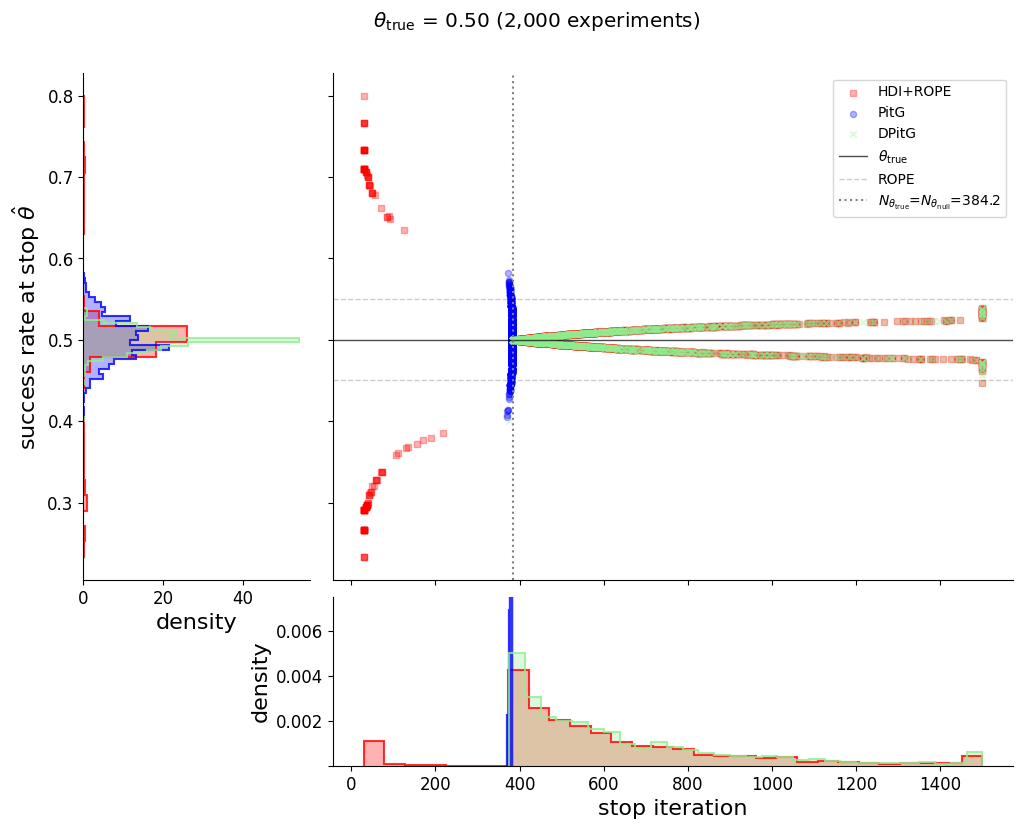

In [31]:
%%time

rope_fracs = [0.7,0.9,1.]

for this_rope_frac in rope_fracs:
    ωgoal = np.round(this_rope_frac * 0.1, 2)

    ωgoal_to_experiments[ωgoal] = run_simulations_and_analysis_report(
        binary_accounting,
        success_rate_true=θ_true,
        success_rate_null=θ_null,
        dsuccess_rate=dsuccess_rate,
        n_experiments=N_EXPERIMENTS,
        n_samples=N_SAMPLES,
        rope_precision_fraction=this_rope_frac,
        seed=SEED,
        viz=True
    )

In [32]:
binary_accounting.save()

Cache saved: 83,058 entries to cache/binary_accounting_0pt95.pkl


In [33]:
report_accounting_size(binary_accounting)

Binary Accounting Report
83,058 elements in 12.18 MBytes)
Most frequent count value: 674 (appears 85 times (of 83,058 0.10%))
Max sum 1,500
e.g, key (np.int64(799), np.int64(701)) appears 5 time(s) yiedling (np.float64(0.5074142760260834), np.float64(0.5578881163957048)) HDI limits

